<a href="https://colab.research.google.com/github/phani-x507/DeepLearning/blob/main/MultiClass_Classification_with_wine_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

In [21]:
data = load_wine()
X = pd.DataFrame(data.data,columns=[data.feature_names])
y = pd.DataFrame(data.target)
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [22]:
X =  np.array(X)
y = np.array(y)
X[0]
np.unique(y)

array([0, 1, 2])

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
x_reduced = pca.fit_transform(x_scaled)

x_reduced[:]

array([[ 3.31675081,  1.44346263],
       [ 2.20946492, -0.33339289],
       [ 2.51674015,  1.0311513 ],
       [ 3.75706561,  2.75637191],
       [ 1.00890849,  0.86983082],
       [ 3.05025392,  2.12240111],
       [ 2.44908967,  1.17485013],
       [ 2.05943687,  1.60896307],
       [ 2.5108743 ,  0.91807096],
       [ 2.75362819,  0.78943767],
       [ 3.47973668,  1.30233324],
       [ 1.7547529 ,  0.61197723],
       [ 2.11346234,  0.67570634],
       [ 3.45815682,  1.13062988],
       [ 4.31278391,  2.09597558],
       [ 2.3051882 ,  1.66255173],
       [ 2.17195527,  2.32730534],
       [ 1.89897118,  1.63136888],
       [ 3.54198508,  2.51834367],
       [ 2.0845222 ,  1.06113799],
       [ 3.12440254,  0.78689711],
       [ 1.08657007,  0.24174355],
       [ 2.53522408, -0.09184062],
       [ 1.64498834, -0.51627893],
       [ 1.76157587, -0.31714893],
       [ 0.9900791 ,  0.94066734],
       [ 1.77527763,  0.68617513],
       [ 1.23542396, -0.08980704],
       [ 2.18840633,

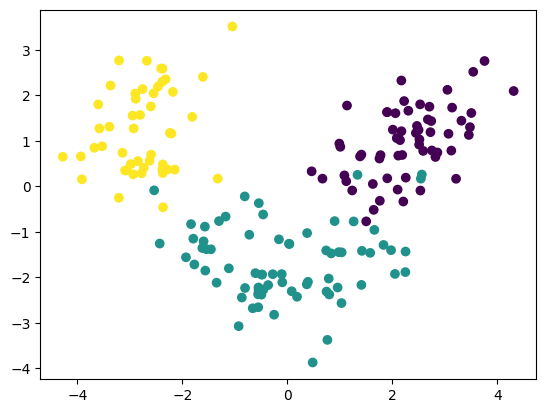

In [24]:
import matplotlib.pyplot as plt

plt.scatter(x_reduced[:,0],x_reduced[:,1] , c=y)

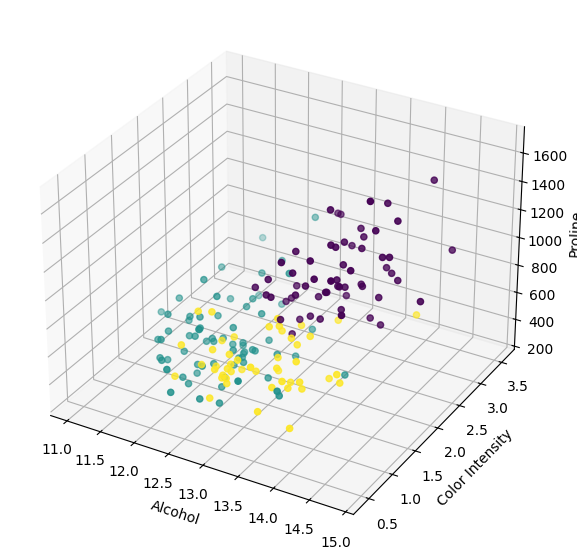

In [25]:
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X[:,0],
    X[:,8],
    X[:,12],
    c=y,

)

ax.set_xlabel("Alcohol")
ax.set_ylabel("Color Intensity")
ax.set_zlabel("Proline")

plt.show()

In [26]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

x_reduced = torch.from_numpy(x_reduced).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)
X_train,X_test,y_train,y_test = train_test_split(x_reduced,y,test_size = 0.2,random_state=RANDOM_SEED)
X_train[:2]



tensor([[-1.0482,  3.5151],
        [-3.9365,  0.6597]])

In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [28]:
class WineModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.stack_layer = nn.Sequential(
        nn.Linear(in_features=2, out_features=64),
        nn.ReLU(),
        nn.Linear(in_features=64,out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128,out_features = 3)
    )

  def forward(self,x):
    return self.stack_layer(x)
wine_model = WineModel().to(device)
wine_model

WineModel(
  (stack_layer): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [32]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=wine_model.parameters(), lr = 0.01)

In [29]:
def acc_fn():


In [35]:
epochs = 2000
X_train,X_test,y_train,y_test = X_train.to(device),X_test.to(device),y_train.to(device),y_test.to(device)

for epoch in range(epochs):
  wine_model.train()
  # first Logits
  y_logits = wine_model(X_train).squeeze(dim=1)

  y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)



  loss = loss_fn(y_logits,y_train.squeeze())


  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  wine_model.eval()

  with torch.inference_mode():
    test_logits = wine_model(X_test)
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits,y_test.squeeze())
  if epoch%100 ==0:
    print(f'loss : {loss:.5f} | test_loss : {test_loss:.5f} | epoch : {epoch} ')

loss : 0.09319 | test_loss : 0.02409 | epoch : 0 
loss : 0.09302 | test_loss : 0.02405 | epoch : 100 
loss : 0.09287 | test_loss : 0.02402 | epoch : 200 
loss : 0.09271 | test_loss : 0.02397 | epoch : 300 
loss : 0.09255 | test_loss : 0.02393 | epoch : 400 
loss : 0.09239 | test_loss : 0.02389 | epoch : 500 
loss : 0.09223 | test_loss : 0.02386 | epoch : 600 
loss : 0.09206 | test_loss : 0.02381 | epoch : 700 
loss : 0.09189 | test_loss : 0.02378 | epoch : 800 
loss : 0.09172 | test_loss : 0.02374 | epoch : 900 
loss : 0.09155 | test_loss : 0.02370 | epoch : 1000 
loss : 0.09138 | test_loss : 0.02366 | epoch : 1100 
loss : 0.09120 | test_loss : 0.02363 | epoch : 1200 
loss : 0.09103 | test_loss : 0.02359 | epoch : 1300 
loss : 0.09085 | test_loss : 0.02356 | epoch : 1400 
loss : 0.09067 | test_loss : 0.02352 | epoch : 1500 
loss : 0.09049 | test_loss : 0.02348 | epoch : 1600 
loss : 0.09030 | test_loss : 0.02345 | epoch : 1700 
loss : 0.09011 | test_loss : 0.02342 | epoch : 1800 
loss 

In [36]:
import requests
from pathlib import Path


if Path("helper_functions.py").is_file():
  print("The file already exists")

else:
  print("Downloading Helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)



In [37]:
from helper_functions import plot_predictions,plot_decision_boundary

[]

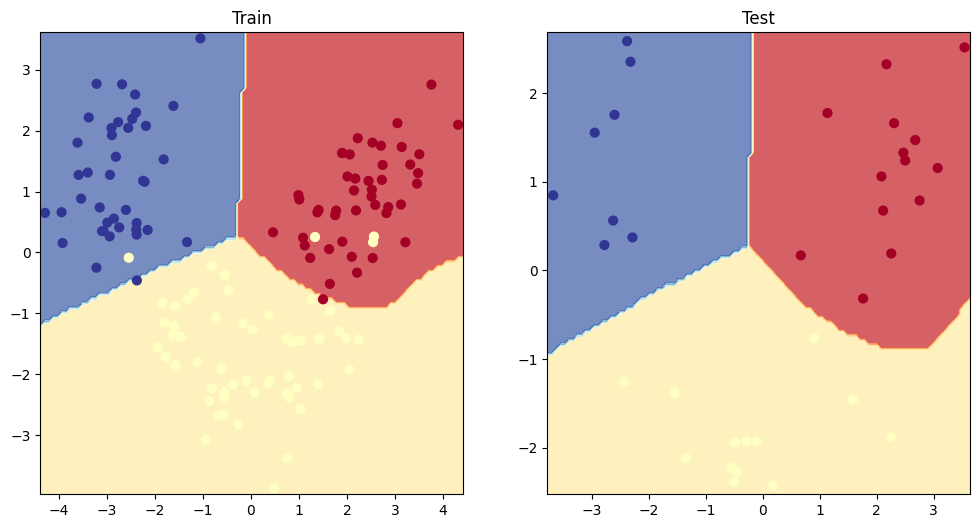

In [38]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(wine_model,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(wine_model,X_test,y_test)

plt.plot()
